## `sim_class_SL_v01.py` 패치에 대한 비교/검증 시각화 자료

#### by 김재헌

### 모듈 및 클래스 load

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
from sim_class import PhotonicGlassMCSimulator
from sim_class_SL_v01 import PhotonicGlassMCSimulator2

sim_old = PhotonicGlassMCSimulator(
    film_thickness = 77.0, #um
    phi = 0.56, 
    fine_roughness=0.5,
    coarse_roughness=0.9,
    r_i=0.138, 
    n_m=1.0, 
    k_p=2e-5, 
    pdi=0.03, 
    detect_angle=90
    )

sim = PhotonicGlassMCSimulator2(
    film_thickness = 77.0, #um
    phi = 0.56, 
    fine_roughness=0.5,
    coarse_roughness=0.9,
    r_i=0.138, 
    n_m=1.0, 
    k_p=2e-5, 
    pdi=0,  
    detect_angle=90
)

Global variable 선언

In [3]:
wvl = 0.55 # um
wvl_array = np.linspace(0.400, 0.800, 1000)
theta_array = np.linspace(1e-4, np.pi-1e-4, 1000)    # radians
theta_deg = np.degrees(theta_array)             # degrees  

### Step 1. effective index, absorption coefficient 확인

In [7]:
n_p = sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
n_eff = sim._get_n_eff_ps_matrix(wvl)
mu_a = sim._get_mu_a(wvl, n_eff)

print("n_p                      =", n_p)
print("n_eff                    =", n_eff)
print("mu_a [1/um]              =", mu_a)
print("absorption length [um]   =", np.inf if mu_a == 0 else 1 / mu_a)

n_p                      = (1.5958939298996344+2e-05j)
n_eff                    = (1.3238414651006658+1.0657361486477478e-05j)
mu_a [1/um]              = 0.00024349882583686138
absorption length [um]   = 4106.795983771918


### Step 2. Schulz distribution 확인

기본적으로는 `pdi=0`, `polydiversity=0`으로 simulator를 생성하기에, Schulz Distribution을 사용하지 않는다. 

하지만 Schulz distriution을 호출하면, numerical safeguard로 인해 distribution이 생성되긴 한다.

`pdi=0.03`으로 설정 시 기존의 분포가 보인다.

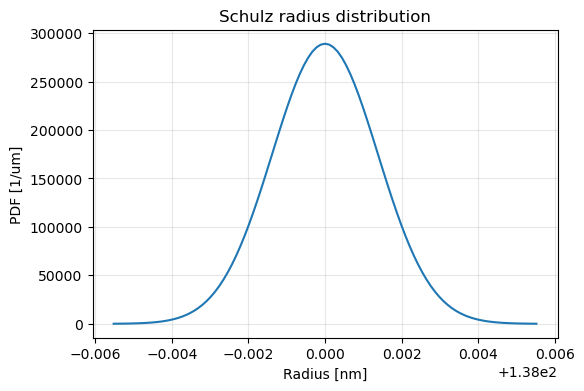

mean radius [um] ≈ 0.13799999999846435
normalization = 1.0000000000000002


In [22]:
radius_samples, size_pdf = sim._get_schulz_distribution(
    n_points=101,
    n_std=4.0,
)

plt.figure(figsize=(6, 4))
plt.plot(radius_samples * 1000, size_pdf)
plt.xlabel("Radius [nm]")
plt.ylabel("PDF [1/um]")
plt.title("Schulz radius distribution")
plt.grid(True, alpha=0.3)
plt.show()

print("mean radius [um] ≈", np.trapezoid(radius_samples * size_pdf, radius_samples))
print("normalization =", np.trapezoid(size_pdf, radius_samples))

### structure factor 비교

기존의 코드는 monodisperse/polydisperse 모두 Ginoza의 structure factor 계산을 쓴다.
하지만 정밀한 계산을 위해 패치 이후는, monodisperse에 대해서는 Percus-Yevick의 계산을 사용한다.

둘은 큰 대세는 비슷하나, 현재는 numerical safeguard가 정밀하게 적용되어 있고, PY의 방식이 단파장에서 더 좁고 높은 피크를 보여준다.

In [23]:
temp_wvl = 0.400 #um

q400 = sim.get_q(np.real(n_eff), theta_array, temp_wvl)
S_q400 = sim._get_structure_factor_percus_yevick(q400)
S_q_old = sim_old._get_structure_factor_ginoza(q)

temp_wvl = 0.500 #um

q500 = sim.get_q(np.real(n_eff), theta_array, temp_wvl)
S_q500 = sim._get_structure_factor_percus_yevick(q500)

temp_wvl = 0.600 #um

q600 = sim.get_q(np.real(n_eff), theta_array, temp_wvl)
S_q600 = sim._get_structure_factor_percus_yevick(q600)

temp_wvl = 0.700 #um

q700 = sim.get_q(np.real(n_eff), theta_array, temp_wvl)
S_q700 = sim._get_structure_factor_percus_yevick(q700)

temp_wvl = 0.800 #um

q800 = sim.get_q(np.real(n_eff), theta_array, temp_wvl)
S_q800 = sim._get_structure_factor_percus_yevick(q800)

data_dict = {
    'q400': q400,
    'S_q400': S_q400,
    'q500': q500,
    'S_q500': S_q500,
    'q600': q600,
    'S_q600': S_q600,
    'q700': q700,
    'S_q700': S_q700,
    'q800': q800,
    'S_q800': S_q800,
}

df = pd.DataFrame(data_dict)

df.to_csv('data/model_structure.csv', index=False )

'''plt.figure(figsize=(6, 4))
plt.plot(theta_deg, S_q, label=f"new-{temp_wvl * 1000}")
plt.plot(theta_deg, S_q_old, label=f"old-{temp_wvl * 1000}")   
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("S(q)")
plt.title("Ginoza measurable structure factor")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()'''

NameError: name 'q' is not defined

Structure Factor의 Variable : 
- 정해진 volume fraction($\phi$)에 대해서 $qd$에 dependant하며, 이때 $d$는 입자의 지름(276nm, 상수)이다.
- 따라서 Structure Factor는 $\theta$(scattering angle)과 wavelength 모두에 depedant하기에 두 변수에 따른 heatmap을 그린다.

그림에서 structure factor의 피크가 보이는 부분을 흰색 점선으로 표시했다. 흰색 점에서의 wavelength와 $\theta$를 이용해 $q$를 계산하면, 모두 동일한 $q$ 값을 지칭함을 알 수 있다.

q_peak [1/um] = 26.28716237156425
theta_peak at 550 nm [deg] = 120.70417965592605


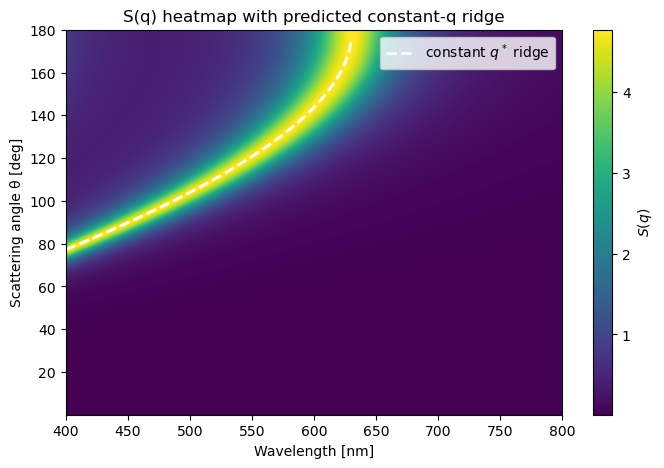

In [24]:
S_map = np.zeros((len(theta_array), len(wvl_array)))
S_max = np.zeros(len(theta_array))
S_min = np.zeros(len(theta_array))

for j, wvl in enumerate(wvl_array):
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    q = sim.get_q(np.real(n_eff), theta_array, wvl)
    S_q = sim._get_structure_factor_percus_yevick(q)
    S_map[:, j] = S_q
    
    S_max[j] = np.max(S_q)
    S_min[j] = np.min(S_q)

# 1) 기준 파장에서 S(q)의 peak q* 찾기
wvl0 = 0.55  # um
n_eff0 = sim._get_n_eff_ps_matrix(wvl0)
q0 = sim.get_q(np.real(n_eff0), theta_array, wvl0)
S0 = sim._get_structure_factor_ginoza(q0)

idx_peak = np.argmax(S0)
q_peak = q0[idx_peak]
theta_peak_deg = np.degrees(theta_array[idx_peak])

print("q_peak [1/um] =", q_peak)
print("theta_peak at 550 nm [deg] =", theta_peak_deg)

# 2) 각 wavelength에서 q_peak에 해당하는 theta 예측
wvls = np.linspace(0.400, 0.800, 300)
theta_ridge = []

for wvl in wvls:
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    arg = q_peak * wvl / (4.0 * np.pi * np.real(n_eff))
    
    if arg <= 1.0:
        theta_ridge.append(2.0 * np.arcsin(arg))
    else:
        theta_ridge.append(np.nan)

theta_ridge = np.array(theta_ridge)

# 3) heatmap 위에 overlay
plt.figure(figsize=(8, 5))
plt.imshow(
    S_map,
    extent=[wvls[0]*1000, wvls[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower",
)
plt.colorbar(label=r"$S(q)$")
plt.plot(wvls * 1000, np.degrees(theta_ridge), "w--", linewidth=2, label=r"constant $q^*$ ridge")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("S(q) heatmap with predicted constant-q ridge")
plt.legend()
plt.show()

각 파장에서 생성되는 Structure Factor의 최댓값과 최솟값

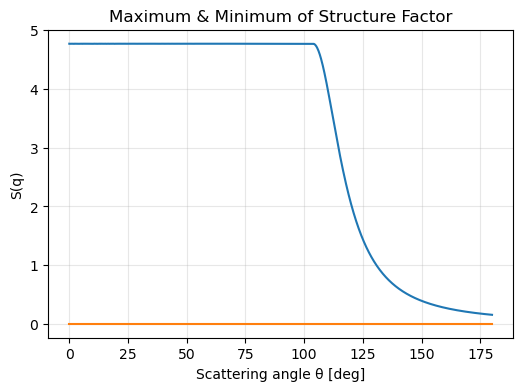

In [30]:
plt.figure(figsize=(6, 4))
plt.plot(theta_deg, S_max, label="S(q) max")
plt.plot(theta_deg, S_min, label="S(q) min")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("S(q)")
plt.title("Maximum & Minimum of Structure Factor")
plt.grid(True, alpha=0.3)
plt.show()

### Step 4. Mie differential cross section 확인

`csca_mie`는 구조 인자를 곱하지 않은 단일입자 산란 단면적:
$C_{sca}^{Mie} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}sinθdθ$

csca_sample은 구조 인자까지 포함한 sample effective scattering cross section:
$C_{sca}^{sample} = 2π∫\frac{dC_{sca}^{Mie}}{dΩ}S(q)sinθdθ$

Monte Carlo의 bulk step size에는 csca_sample이 들어가야 해. SI에서 scattering length를
$l_{sca}= \frac{1}{ρC_{sca}^{sample}}$



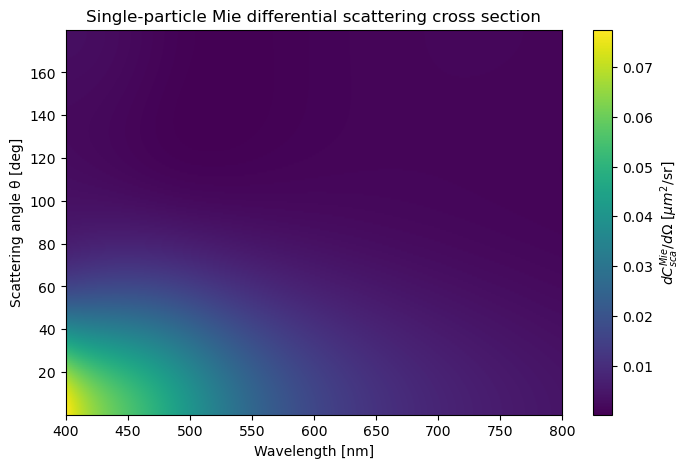

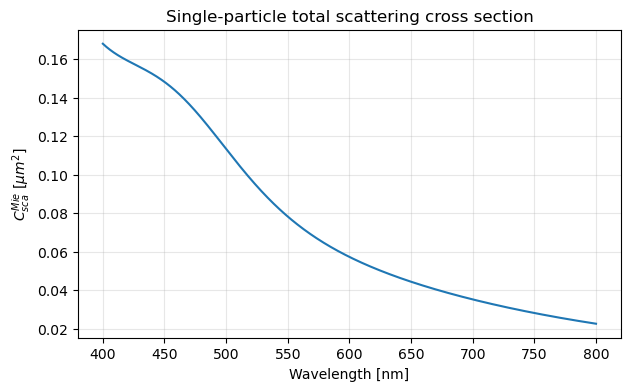

In [5]:
mie_map = np.zeros((len(theta_array), len(wvl_array)))
csca_mie_list = []

for j, wvl in enumerate(wvl_array):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    n_matrix = 1.0 + 0.0j
    
    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p_complex,
        n_host_complex=n_matrix,
        theta_array=theta_array,
        backend="internal",
    )
    
    mie_map[:, j] = diff_mie
    csca_mie_list.append(csca_mie)

csca_mie_list = np.asarray(csca_mie_list)
l_scat_mie_list = sim._get_l_scat(csca_mie_list)

l_scat_mie_list = np.asarray(l_scat_mie_list)
mu_scat_mie = 1/l_scat_mie_list
data_dict = {
    'wvls': wvl_array,
    'l_scat_mie': l_scat_mie_list,
    'mu_scat_mie': mu_scat_mie,
}

df = pd.DataFrame(data_dict)

df.to_csv('data/model_mu_mie_new.csv', index=False )

plt.figure(figsize=(8, 5))
plt.imshow(
    mie_map,
    extent=[wvl_array[0]*1000, wvl_array[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$dC_{sca}^{Mie}/d\Omega$ [$\mu m^2$/sr]")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Scattering angle θ [deg]")
plt.title("Single-particle Mie differential scattering cross section")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, csca_mie_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$C_{sca}^{Mie}$ [$\mu m^2$]")
plt.title("Single-particle total scattering cross section")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
rho = 3 * sim.phi / (4*np.pi*sim.r_i**3)
geom = np.pi * sim.r_i**2

for wvl in [0.4, 0.5, 0.8]:
    n_eff = sim._get_n_eff_ps_matrix(wvl)
    n_p = sim.get_n_p_real_sellmeier(wvl) + 1j*sim.k_p

    phase, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )

    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wvl,
        n_p_complex=n_p,
        n_host_complex=n_eff,
        theta_array=theta_array,
        backend="internal",
    )

    print(f"\nλ={wvl*1000:.0f} nm")
    print("csca_mie     =", csca_mie, "Q_mie =", csca_mie/geom)
    print("csca_sample  =", csca_sample, "Q_sample =", csca_sample/geom)
    print("Weigthed S(q)=", csca_sample / csca_mie)
    print("l_scat_mie   =", 1/(rho*csca_mie))
    print("l_scat_sample=", 1/(rho*csca_sample))
    print("rho          =", rho)


λ=400 nm
csca_mie     = 0.04190292818070824 Q_mie = 0.7003841787423227
csca_sample  = 0.004173714370214959 Q_sample = 0.06976131832318709
Weigthed S(q)= 0.099604360635983
l_scat_mie   = 0.4691302838414241
l_scat_sample= 4.7099372040138014
rho          = 50.870049297428714

λ=500 nm
csca_mie     = 0.02289504274248819 Q_mie = 0.38267792740676526
csca_sample  = 0.0016057327175673368 Q_sample = 0.026838930821804656
Weigthed S(q)= 0.0701345149527696
l_scat_mie   = 0.8586108710215091
l_scat_sample= 12.24234418103155
rho          = 50.870049297428714

λ=800 nm
csca_mie     = 0.006105270209392458 Q_mie = 0.10204620171565852
csca_sample  = 0.00016442532157174268 Q_sample = 0.0027482779560614678
Weigthed S(q)= 0.02693170259995828
l_scat_mie   = 3.2198300676291685
l_scat_sample= 119.55538479896019
rho          = 50.870049297428714


In [8]:
scat_theta_list = []

for j, wvl in enumerate([0.4, 0.5, 0.6, 0.7, 0.8]):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    
    # phase_func : normalized, 구면적분 시 1
    # csca_sample : diff_sample에 대해 구면적분 한 결과
    # diff_sample : diff_mie * S_q 만 된 상태
    # phase_func = diff_sample / csca_sample
    phase_func, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )
    temp_scat = []
    cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)
    for _ in range(200000):
        rand_cdf = np.random.rand()  
        scat_theta = np.interp(rand_cdf, cdf, theta_array)
        temp_scat.append(scat_theta)
        
    scat_theta_list.append(temp_scat)

data_dict = {
    'scat400': scat_theta_list[0],
    'scat500': scat_theta_list[1],
    'scat600': scat_theta_list[2],
    'scat700': scat_theta_list[3],
    'scat800': scat_theta_list[4]
}

df = pd.DataFrame(data_dict)

df.to_csv('data/model_cdf_val.csv', index=False )

### Step 4. phase function / sample cross section 확인 & Step 5. CDF 확인

In [ ]:
phase_map = np.zeros((len(theta_array), len(wvl_array)))
diff_sample_map = np.zeros((len(theta_array), len(wvl_array)))
pdf_map = np.zeros((len(theta_array), len(wvl_array)))
cdf_map = np.zeros((len(theta_array), len(wvl_array)))
csca_sample_list = []
l_scat_list = []
l_star_list = []
g_list = []

for j, wvl in enumerate(wvl_array):
    n_p_complex = sim.get_n_p_real_sellmeier(wvl) +  1j * sim.k_p
    n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
    
    # phase_func : normalized, 구면적분 시 1
    # csca_sample : diff_sample에 대해 구면적분 한 결과
    # diff_sample : diff_mie * S_q 만 된 상태
    # phase_func = diff_sample / csca_sample
    phase_func, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wvl,
        theta_array=theta_array,
        backend="internal",
    )
    
    cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)
    l_scat = sim._get_l_scat(csca_sample)
    l_star, g = sim._get_l_star(l_scat, theta_pdf, theta_array)
    
    cdf_map[:, j] = cdf
    pdf_map[:, j] = theta_pdf
    phase_map[:, j] = phase_func
    diff_sample_map[:, j] = diff_sample
    csca_sample_list.append(csca_sample)
    l_scat_list.append(l_scat)
    l_star_list.append(l_star)
    g_list.append(g)

csca_sample_list = np.asarray(csca_sample_list)
l_scat_list = np.asarray(l_scat_list)

np.savez(
    "data/model_phase.npz",
    wvls=np.asarray(wvl_array),
    phase=np.asarray(phase_map),
    csca=np.asarray(csca_sample_list),
)

#### Phase Function Heat Map

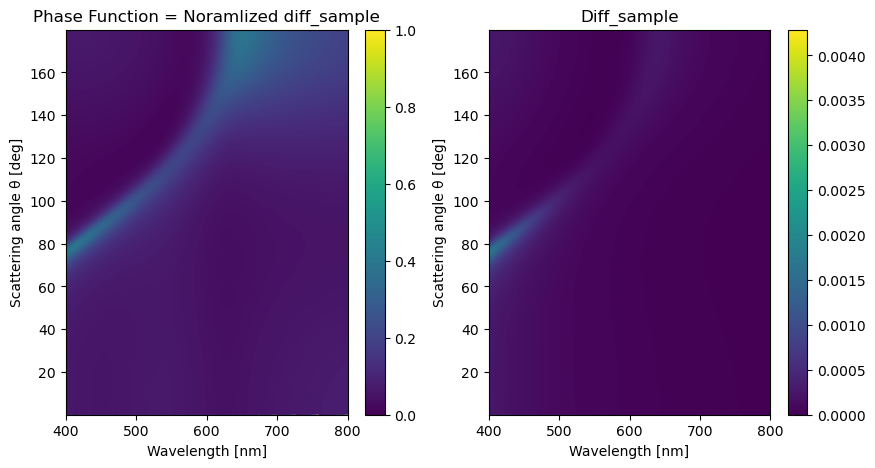

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---------------- PDF ----------------
im1 = axes[0].imshow(phase_map, extent=[wvl_array[0]*1000, wvl_array[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto", origin="lower", vmin=0, vmax=1.0)

axes[0].set_xlabel("Wavelength [nm]")
axes[0].set_ylabel("Scattering angle θ [deg]")
axes[0].set_title("Phase Function = Noramlized diff_sample")

fig.colorbar(im1, ax=axes[0])

# ---------------- CDF ----------------
im2 = axes[1].imshow(diff_sample_map, extent=[wvl_array[0]*1000, wvl_array[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto", origin="lower")

axes[1].set_xlabel("Wavelength [nm]")
axes[1].set_ylabel("Scattering angle θ [deg]")
axes[1].set_title("Diff_sample")

fig.colorbar(im2, ax=axes[1])

#### Single-particle total scattering cross section

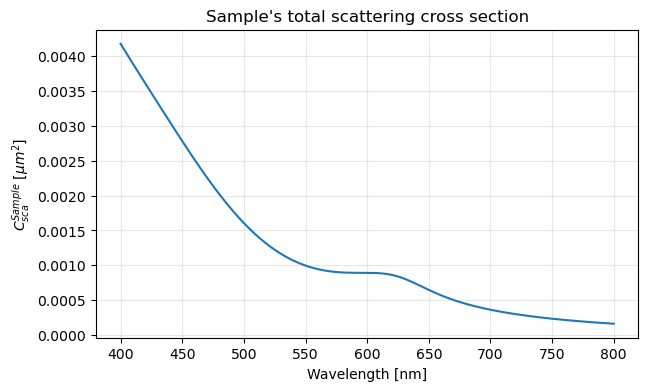

In [33]:
plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, csca_sample_list)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$C_{sca}^{Sample}$ [$\mu m^2$]")
plt.title("Sample's total scattering cross section")
plt.grid(True, alpha=0.3)
plt.show()

#### $l_{scat}$ & $l_{trans}$ by wavelength

논문에서는 transport length가 8 - 47um 범위에 존재한다고 말함

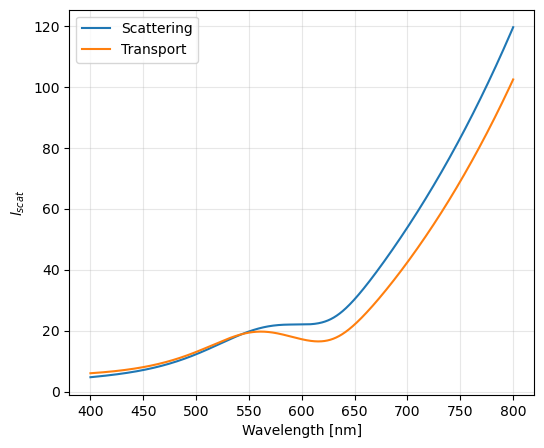

6.015335254766082 102.40592268672272


In [34]:
plt.figure(figsize=(6, 5))
plt.plot(wvl_array * 1000, l_scat_list, label="Scattering")
plt.plot(wvl_array * 1000, l_star_list, label="Transport")
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$l_{scat}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(l_star_list[0], l_star_list[-1])

$l_{trans} = \frac{l_{sca}}{1-<\cos >}$ 인데, $l_{trans}$이 너무 작기에, $l_{sca}$을 만드는 $C_{sca}^{sample}$을 조사한다

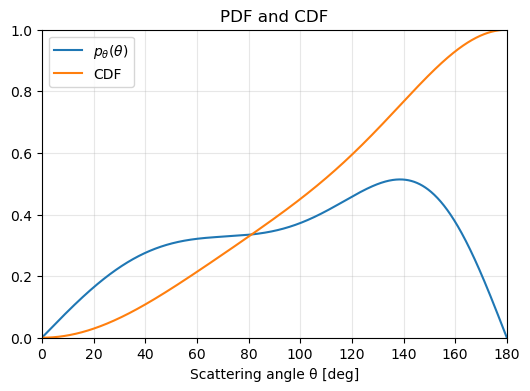

In [35]:
cdf, theta_pdf = sim._cdf_phase(phase_func, theta_array)

plt.figure(figsize=(6, 4))
plt.plot(theta_deg, theta_pdf, label=r"$p_\theta(\theta)$")
plt.plot(theta_deg, cdf, label="CDF")
plt.xlabel("Scattering angle θ [deg]")
plt.title("PDF and CDF")
plt.legend()
plt.ylim(0, 1.0)
plt.xlim(0, 180)
plt.grid(True, alpha=0.3)
plt.show()

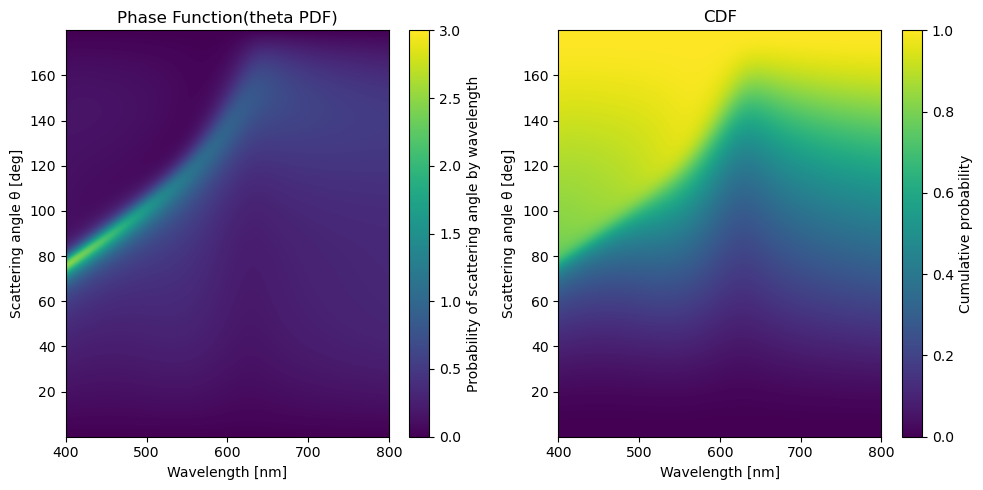

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---------------- PDF ----------------
im1 = axes[0].imshow(pdf_map, extent=[wvl_array[0]*1000, wvl_array[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto", origin="lower", vmin=0, vmax=3)

axes[0].set_xlabel("Wavelength [nm]")
axes[0].set_ylabel("Scattering angle θ [deg]")
axes[0].set_title("Phase Function(theta PDF)")

fig.colorbar(im1, ax=axes[0], label="Probability of scattering angle by wavelength")

# ---------------- CDF ----------------
im2 = axes[1].imshow(cdf_map, extent=[wvl_array[0]*1000, wvl_array[-1]*1000, theta_deg[0], theta_deg[-1]],
    aspect="auto", origin="lower")

axes[1].set_xlabel("Wavelength [nm]")
axes[1].set_ylabel("Scattering angle θ [deg]")
axes[1].set_title("CDF")

fig.colorbar(im2, ax=axes[1], label="Cumulative probability")

plt.tight_layout()
plt.show()

In [ ]:
for wavelength in [0.4, 0.5, 0.6, 0.7, 0.8]:
    n_eff_complex = sim._get_n_eff_ps_matrix(wavelength)
    n_p_complex = sim.get_n_p_real_sellmeier(wavelength) + 1j * sim.k_p

    diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
        wavelength=wavelength,
        n_p_complex=n_p_complex,
        n_host_complex=n_eff_complex,
        theta_array=theta_array,
        backend="internal"
    )

    q = sim.get_q(np.real(n_eff_complex), theta_array, wavelength)
    S_q = sim._get_structure_factor_ginoza(q)
    diff_sample = diff_mie * S_q

    # backward hemisphere contribution: theta > 90 deg
    mask_back = theta_array > np.pi / 2

    c_back = 2*np.pi*np.trapezoid(
        diff_sample[mask_back] * np.sin(theta_array[mask_back]),
        theta_array[mask_back]
    )

    c_total = 2*np.pi*np.trapezoid(
        diff_sample * np.sin(theta_array),
        theta_array
    )

    print(
        wavelength,
        "C_total =", c_total,
        "C_back =", c_back,
        "back fraction =", c_back / c_total
    )

0.4 C_total = 0.004173891291938477 C_back = 0.0007995009130657935 back fraction = 0.19154809197114522
0.5 C_total = 0.0016057990935328858 C_back = 0.0008388550647711274 back fraction = 0.5223910439042405
0.6 C_total = 0.0008934869736397439 C_back = 0.0006375277232703244 back fraction = 0.7135277201336985
0.7 C_total = 0.00036475481618818324 C_back = 0.00024608682367836376 back fraction = 0.67466367202511
0.8 C_total = 0.00016443926351595654 C_back = 0.00010062715126078989 back fraction = 0.6119411453763014


파장별 인자 분석

In [ ]:
def diagnostic_one_wavelength(
    sim,
    wavelength,
    theta_array,
    backend="internal",
    use_polydispersity=False,
    radius_samples=None,
    size_pdf=None,
    run_mc=False,
    N_photons=2000,
):
    """
    wavelength 단위: μm
    theta_array 단위: rad

    출력:
    csca_mie, csca_sample, weighted_S, l_scat, g, l_transport,
    backward cross-section fraction, optional R/T/A.
    """

    theta_array = np.asarray(theta_array, dtype=float)

    # 1. Optical constants
    n_eff_complex_mg = sim._get_n_eff_ps_matrix_mg(wavelength)
    n_eff_mg_real = float(np.real(n_eff_complex_mg))
    n_p_complex = sim.get_n_p_real_sellmeier(wavelength) + 1j * sim.k_p
    mu_a_mg = sim._get_mu_a(wavelength, n_eff_complex_mg)

    n_eff_complex_bg = sim._get_n_eff_ps_matrix(wavelength)
    n_eff_bg_real = float(np.real(n_eff_complex_bg))
    mu_a_bg = sim._get_mu_a(wavelength, n_eff_complex_bg)
    
    # 2. Mie-only cross section
    if use_polydispersity:
        if radius_samples is None or size_pdf is None:
            radius_samples, size_pdf = sim._get_schulz_distribution()

        diff_mie, csca_mie = sim._get_polydisperse_form_factor_absorbing(
            wavelength=wavelength,
            n_p_complex=n_p_complex,
            n_host_complex=n_eff_complex_bg,
            theta_array=theta_array,
            radius_samples=radius_samples,
            size_pdf=size_pdf,
            backend=backend,
        )
    else:
        diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
            wavelength=wavelength,
            n_p_complex=n_p_complex,
            n_host_complex=n_eff_complex_bg,
            theta_array=theta_array,
            backend=backend,
        )

    # 3. Structure factor
    q = sim.get_q(np.real(n_eff_complex_bg), theta_array, wavelength)
    S_q = sim._get_structure_factor_ginoza(q)
    S_q = np.asarray(np.real_if_close(S_q), dtype=float)
    S_q = np.clip(S_q, 0.0, None)

    # 4. Sample differential cross-section    
    phase_func, csca_sample, diff_sample = sim._get_phase_func_ginoza(
        wavelength=wavelength,
        theta_array=theta_array,
        backend="internal",
    )

    weighted_S = csca_sample / csca_mie

    # 5. Scattering length
    rho = (sim.phi * 3.0) / (4.0 * np.pi * sim.r_i**3)
    l_scat = sim._get_l_scat(csca_sample)
    l_scat_mie = sim._get_l_scat(csca_mie)

    # 6. Phase function and theta PDF
    phase = diff_sample / csca_sample
    phase_norm = 2.0 * np.pi * np.trapezoid(
        phase * np.sin(theta_array),
        theta_array
    )
    phase = phase / phase_norm

    cdf_norm, theta_pdf = sim._cdf_phase(phase, theta_array)

    # 7. Anisotropy factor and transport length
    l_transport, g = sim._get_l_star(l_scat, theta_pdf, theta_array)

    # 8. Backward hemisphere contribution
    mask_back = theta_array > (np.pi / 2.0)

    C_back = 2.0 * np.pi * np.trapezoid(
        diff_sample[mask_back] * np.sin(theta_array[mask_back]),
        theta_array[mask_back]
    )

    back_fraction = C_back / csca_sample

    # 9. Surface phase and CDF for optional MC
    phase_surf = diff_mie / csca_mie
    phase_surf_norm = 2.0 * np.pi * np.trapezoid(
        phase_surf * np.sin(theta_array),
        theta_array
    )
    phase_surf = phase_surf / phase_surf_norm
    
    cdf_surf, theta_pdf_surf = sim._cdf_phase(phase_surf, theta_array)
    
    result = {
        "wavelength_um": wavelength,
        "wavelength_nm": wavelength * 1000.0,
        "n_eff_mg_real": n_eff_mg_real,
        "n_eff_mg_imag": float(np.imag(n_eff_complex_mg)),
        "n_eff_bg_real": n_eff_bg_real,
        "n_eff_bg_imag": float(np.imag(n_eff_complex_bg)),
        "mu_a_mg": mu_a_mg,
        "mu_a_bg": mu_a_bg,
        "rho": rho,
        "csca_mie": csca_mie,
        "csca_sample": csca_sample,
        "Q_mie": csca_mie / (np.pi * sim.r_i**2),
        "Q_sample": csca_sample / (np.pi * sim.r_i**2),
        "weighted_S": weighted_S,
        "S_min": float(np.min(S_q)),
        "S_max": float(np.max(S_q)),
        "C_back": C_back,
        "back_fraction": back_fraction,
        "g": g,
        "l_scat_mie_um": l_scat_mie,
        "l_scat_sample_um": l_scat,
        "l_transport_um": l_transport,
        "lambda_over_l_transport": wavelength / l_transport,
    }

    # 10. Optional Monte Carlo R/T/A
    if run_mc:
        R, T, A, diag = sim._run_single_wavelength(
            N_photons=N_photons,
            theta_array=theta_array,
            mu_a=mu_a_bg,
            l_scat_norm=l_scat,
            cdf_norm=cdf_norm,
            l_scat_surf=l_scat_mie,
            cdf_surf=cdf_surf,
            n_eff_real=n_eff_bg_real,
            return_diagnostics=True,
        )

        result.update({
            "R": R,
            "T": T,
            "A": A,
            "mean_scatters": diag["mean_scatters"],
            "median_scatters": diag["median_scatters"],
            "mean_path": diag["mean_path"],
            "median_path": diag["median_path"],
            "mean_final_weight": diag["mean_final_weight"],
            "n_reflected": diag["status_count"].get("reflected", 0),
            "n_transmitted": diag["status_count"].get("transmitted", 0),
            "n_absorbed": diag["status_count"].get("absorbed", 0),
            "n_max_events": diag["status_count"].get("max_events", 0),
        })

    return result


def build_diagnostic_table(
    sim,
    wavelengths,
    theta_array,
    backend="internal",
    use_polydispersity=False,
    run_mc=False,
    N_photons=2000,
):
    """
    wavelengths 단위: μm
    예: np.array([0.4, 0.45, 0.5, ..., 0.8])
    """

    if use_polydispersity:
        radius_samples, size_pdf = sim._get_schulz_distribution()
    else:
        radius_samples, size_pdf = None, None

    rows = []

    for wvl in wavelengths:
        row = diagnostic_one_wavelength(
            sim=sim,
            wavelength=float(wvl),
            theta_array=theta_array,
            backend=backend,
            use_polydispersity=use_polydispersity,
            radius_samples=radius_samples,
            size_pdf=size_pdf,
            run_mc=run_mc,
            N_photons=N_photons,
        )
        rows.append(row)

    df = pd.DataFrame(rows)

    # 보기 좋은 column 순서
    base_cols = [
        "wavelength_nm",
        "csca_mie",
        "csca_sample",
        "Q_mie",
        "Q_sample",
        "weighted_S",
        "S_min",
        "S_max",
        "C_back",
        "back_fraction",
        "g",
        "l_scat_mie_um",
        "l_scat_sample_um",
        "l_transport_um",
        "lambda_over_l_transport",
        "rho",
        "n_eff_mg_real",
        "n_eff_mg_imag",
        "n_eff_bg_real",
        "n_eff_bg_imag",
        "mu_a_mg",
        "mu_a_bg",
    ]

    mc_cols = [
        "R",
        "T",
        "A",
        "mean_scatters",
        "median_scatters",
        "mean_path",
        "median_path",
        "mean_final_weight",
        "n_reflected",
        "n_transmitted",
        "n_absorbed",
        "n_max_events",
    ]

    cols = base_cols + [c for c in mc_cols if c in df.columns]
    df = df[cols]

    return df

In [6]:
#theta_array = np.linspace(0.01, np.pi - 0.01, 1000)
wavelengths = np.linspace(0.4, 0.8, 81)

df_diag = build_diagnostic_table(
    sim=sim,
    wavelengths=wavelengths,
    theta_array=theta_array,
    backend="internal",
    use_polydispersity=False,
    run_mc=False,
)

pd.set_option("display.max_columns", None)
#display(df_diag)

df_diag.to_csv("diagnostic_table.csv", index=False)


### Step 9 : `_get_norm_vec` 검증

mean tilt angle [deg]: 44.42925182136302
RMS slope magnitude: 1.2704833726250402
target coarse roughness: 0.9


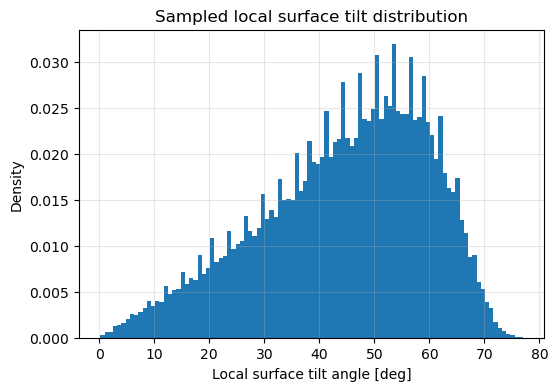

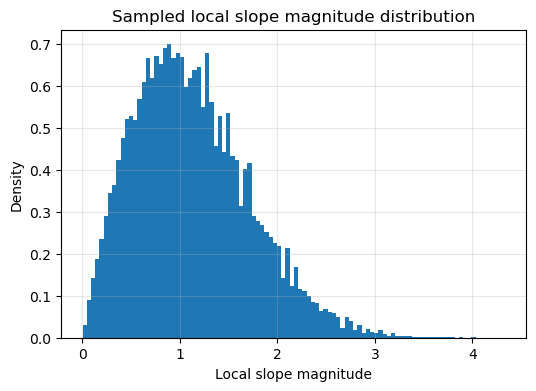

In [28]:
N = 100000
normals = np.array([sim._get_norm_vec(upward=True) for _ in range(N)])

tilt_angle = np.degrees(np.arccos(np.clip(normals[:, 2], -1, 1)))
slope_mag = np.sqrt((normals[:, 0] / normals[:, 2])**2 +
                    (normals[:, 1] / normals[:, 2])**2)

print("mean tilt angle [deg]:", tilt_angle.mean())
print("RMS slope magnitude:", np.sqrt(np.mean(slope_mag**2)))
print("target coarse roughness:", sim.coarse_roughness)

plt.figure(figsize=(6, 4))
plt.hist(tilt_angle, bins=100, density=True)
plt.xlabel("Local surface tilt angle [deg]")
plt.ylabel("Density")
plt.title("Sampled local surface tilt distribution")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(slope_mag, bins=100, density=True)
plt.xlabel("Local slope magnitude")
plt.ylabel("Density")
plt.title("Sampled local slope magnitude distribution")
plt.grid(True, alpha=0.3)
plt.show() 

data_dict = {
    'theta_a': sim._theta_a_grid,
    'prob': sim._theta_a_prob,
}

df = pd.DataFrame(data_dict)

df.to_csv('data/model_theta_a.csv', index=False )

In [ ]:
n_eff_complex = sim._get_n_eff_ps_matrix(wvl)
n_eff_real = np.real(n_eff_complex)
mu_a = sim._get_mu_a(wvl, n_eff_complex)

phase_norm, csca_sample, diff_sample = sim._get_phase_func_ginoza(
    wavelength=wvl,
    theta_array=theta_array,
    backend="internal",
)
cdf_norm, _ = sim._cdf_phase(phase_norm, theta_array)
l_scat_norm = sim._get_l_scat(csca_sample)

n_p_complex = sim.get_n_p_real_sellmeier(wvl) + 1j * sim.k_p
diff_mie, csca_mie, _, _ = sim._get_mie_absorbing(
    wavelength=wvl,
    n_p_complex=n_p_complex,
    n_host_complex=n_eff_complex,
    theta_array=theta_array,
    backend="internal",
)
phase_surf = diff_mie / csca_mie
phase_surf /= 2*np.pi*np.trapezoid(phase_surf*np.sin(theta_array), theta_array)
cdf_surf, _ = sim._cdf_phase(phase_surf, theta_array)
l_scat_surf = sim._get_l_scat(csca_mie)

result = sim._track_single_photon(
    mu_a=mu_a,
    l_scat_norm=l_scat_norm,
    cdf_norm=cdf_norm,
    l_scat_surf=l_scat_surf,
    cdf_surf=cdf_surf,
    theta_array=theta_array,
    n_eff_real=n_eff_real,
    trace=True,
)

print(result["status"])
print("R =", result["R"], "T =", result["T"], "W =", result["W"])
print("n_scat =", result["n_scat"], "path =", result["path"])

trace = result["trace"]
xs = np.array([r[0] for r in trace])
zs = np.array([r[2] for r in trace])
events = [r[4] for r in trace]

plt.figure(figsize=(7, 6))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.axhline(sim.film_thickness, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title(f"Single photon trace: {result['status']}")
plt.gca().invert_yaxis()  # optional: top surface visually at top
plt.grid(True, alpha=0.3)
plt.show()

for i, e in enumerate(events):
    print(f"#{i} event: {e}")

NameError: name 'sim' is not defined

In [ ]:
trace = result["trace"]
xs = np.array([r[0] for r in trace])
zs = np.array([r[2] for r in trace])
events = [r[4] for r in trace]

plt.figure(figsize=(7, 4))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.axhline(sim.film_thickness, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title(f"Single photon trace: {result['status']}")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(xs, zs, marker="o", markersize=2)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("x [um]")
plt.ylabel("z [um]")
plt.title("Zoom near top surface")
plt.ylim(-0.1, 5.0)
plt.grid(True, alpha=0.3)
plt.show()

print("events:", events[:30])

In [ ]:
print("l_scat_norm =", l_scat_norm)
print("l_scat_surf =", l_scat_surf)
print("ratio surf/norm =", l_scat_surf / l_scat_norm)

### Fresnel reflection and Transmission

In [5]:
temp_wvl = 0.550

n_p_complex = sim.get_n_p_real_sellmeier(temp_wvl) +  1j * sim.k_p
n_eff_complex = sim._get_n_eff_ps_matrix(temp_wvl)
n_matrix = 1.0 + 0.0j

theta_arr = np.linspace(0, np.pi / 2, 500)

fresnel_refl_list = []
for theta in theta_arr:
    cos_theta = np.cos(theta)
    fresnel_refl, _, _ = sim._calculate_fresnel_refl(n_matrix, n_eff_complex, cos_theta)
    fresnel_refl_list.append(fresnel_refl)
    print(fresnel_refl)
    
data_dict = {
    'theta':theta_arr,
    'fresnel_refl': fresnel_refl_list,
}

df = pd.DataFrame(data_dict)

df.to_csv('data/model_fresnel.csv', index=False )

0.019420120389108186
0.019420120390153166
0.01942012040582837
0.01942012047375784
0.019420120656659663
0.019420121042362716
0.01942012174383026
0.019420122899190366
0.019420124671773002
0.019420127250153955
0.0194201308482055
0.019420135705153923
0.01942014208564384
0.01942015027980935
0.01942016060335209
0.019420173397626174
0.019420189029729973
0.01942020789260502
0.01942023040514159
0.019420257012291685
0.019420288185188674
0.019420324421274275
0.019420366244432576
0.019420414205131145
0.01942046888056949
0.019420530874834616
0.01942060081906402
0.019420679371615984
0.019420767218247155
0.01942086507229778
0.019420973674884386
0.019421093795099945
0.01942122623022178
0.019421371805927123
0.01942153137651654
0.019421705825145005
0.019421896064061084
0.019422103034853984
0.019422327708708734
0.019422571086669442
0.019422834199910866
0.01942311811001818
0.019423423909275338
0.01942375272096162
0.019424105699657107
0.01942448403155653
0.019424888934792182
0.01942532165976541
0.019425783

### 전 파장 시뮬레이션

MC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

MC Simulation: 100%|██████████| 1000/1000 [39:17<00:00,  2.36s/it] 


npzs/mc_77um_test_v02.npz is successfully saved!


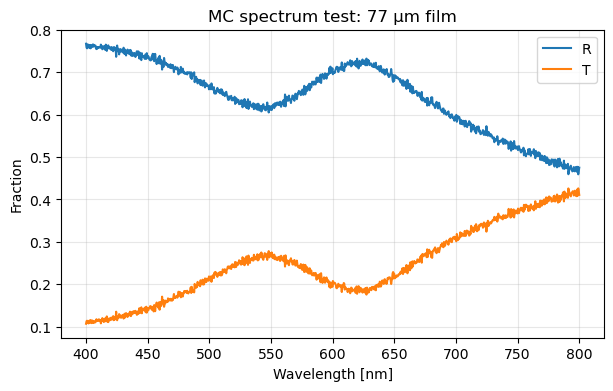

In [24]:
filename = "npzs/mc_77um_test_v02"


R, T, _, _ = sim.run_simulation(
    wvls=wvl_array,
    theta_array=theta_array,
    N_photons=5000,
    backend="internal",
    use_polydispersity=False,
    return_diagnostics=True,
    save_filename=filename
)

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, R, label="R")
plt.plot(wvl_array * 1000, T, label="T")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Fraction")
plt.title("MC spectrum test: 77 µm film")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Debugging을 위한 로그 데이터

In [ ]:
for d in diags:
    print(
        f"{d['wavelength']*1000:.0f} nm | "
        f"R={R[list(wvl_array).index(d['wavelength'])]:.3f}, "
        f"T={T[list(wvl_array).index(d['wavelength'])]:.3f}, "
        f"A={A[list(wvl_array).index(d['wavelength'])]:.3f} | "
        f"l_norm={d['l_scat_norm']:.3f}, "
        f"l_surf={d['l_scat_surf']:.3f}, "
        f"mu_a={d['mu_a']:.3e}, "
        f"mean_scat={d['mean_scatters']:.1f}, "
        f"status={d['status_count']}"
    )

In [ ]:
l_norm = np.array([d["l_scat_norm"] for d in diags])
l_surf = np.array([d["l_scat_surf"] for d in diags])
mu_a_arr = np.array([d["mu_a"] for d in diags])
mean_scat = np.array([d["mean_scatters"] for d in diags])

plt.figure(figsize=(7, 4))
plt.plot(wvl_array * 1000, mean_scat)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Mean number of scatters")
plt.title("Mean scattering events per photon")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
for d in diags:
    max_events = d["status_count"].get("max_events", 0)
    if max_events > 0:
        print("max_events warning:", d["wavelength"], max_events)

### Overlay data on the figure from the papaer

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def overlay_figure(filename, img_path, save_path):
    data = np.load(f"{filename}.npz")
    #data = pd.read_csv(f"{filename}.csv")
    R = data["reflectance"]
    #R = data["R"]
    #T = data["transmittance"]
    wvls = data["wavelengths"]
    #wvls = data["wvls"]
    
    # Load Background Image
    img = Image.open(f"{img_path}.png")

    fig, ax = plt.subplots(figsize=(6, 5))

    # Put Reference Image at the background
    ax.imshow(img, extent=[400, 800, 0, 100], aspect="auto")

    # Overlay my graph
    ax.plot(wvls*1000, R*100, linewidth=1.0, label="R")
    #ax.plot(wvls*1000, T*100, linewidth=1.0, label="T")
    ax.set_xlim(400, 800)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("(%)")
    ax.legend()
    plt.savefig(f"{save_path}.png", transparent=True)
    plt.show()
    
    


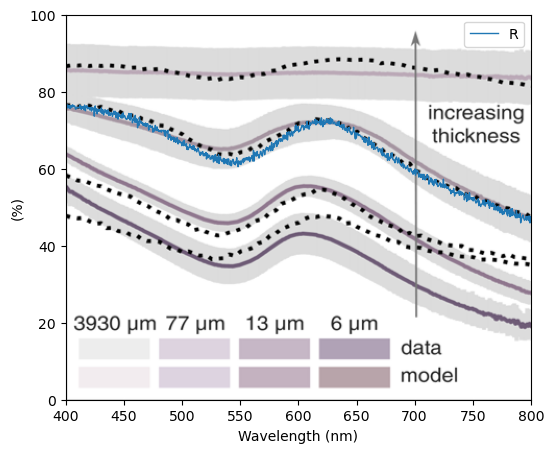

In [26]:
overlay_figure("npzs/mc_77um_test_v02", "figure3c", "overlays/overlayed_data_model_v02")

### 개선 여지가 있는 것들

1. normalization 여부 검토 
2. roughness에 대한 구현을 소스코드와 비교
3. absorption diagnostic? 
4. 하드웨어 및 Monte Carlo 조건 검토


In [11]:
init = sim.initialize(n_eff, 20000, 300, 8.0, coarse_roughness=0.9)
position, direction, weight, kz0_rot, kz0_refl = init
print(kz0_rot.shape)

(20000,)


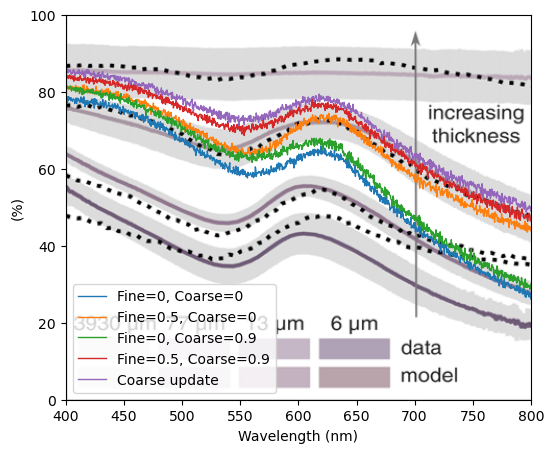

In [ ]:
filename = f"npzs\mc_77um_rough_test"
data = np.load(f"{filename}_0.npz")
R0 = data["reflectance"]
wvls = data["wavelengths"]

data = np.load(f"{filename}_1.npz")
R1 = data["reflectance"]

data = np.load(f"{filename}_2.npz")
R2 = data["reflectance"]

data = np.load(f"{filename}_3.npz")
R3 = data["reflectance"]

data = np.load(f"npzs\mc_77um_test_rough_update.npz")
R4 = data["reflectance"]

# Load Background Image
img_path="figure3c"
img = Image.open(f"{img_path}.png")

fig, ax = plt.subplots(figsize=(6, 5))

# Put Reference Image at the background
ax.imshow(img, extent=[400, 800, 0, 100], aspect="auto")

# Overlay my graph
ax.plot(wvls*1000, R0*100, linewidth=1.0, label="Fine=0, Coarse=0")
ax.plot(wvls*1000, R1*100, linewidth=1.0, label="Fine=0.5, Coarse=0")
ax.plot(wvls*1000, R2*100, linewidth=1.0, label="Fine=0, Coarse=0.9")
ax.plot(wvls*1000, R3*100, linewidth=1.0, label="Fine=0.5, Coarse=0.9")
ax.plot(wvls*1000, R4*100, linewidth=1.0, label="Coarse update")
ax.set_xlim(400, 800)
ax.set_ylim(0, 100)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("(%)")
ax.legend()

plt.show()


# Coarse Roughness에 의한 기울기 저장해두기